In [ ]:
import pandas as pd
df=pd.read_csv("dataset/metrics_data.csv")
df.shape


(15771, 3)

In [3]:
df.head

<bound method NDFrame.head of                      timestamp                              metric  value
0      2026-03-22 22:27:19.851  http_server_requests_seconds_count    1.0
1      2026-03-22 22:27:34.851  http_server_requests_seconds_count    1.0
2      2026-03-22 22:27:49.851  http_server_requests_seconds_count    1.0
3      2026-03-22 22:28:04.851  http_server_requests_seconds_count    1.0
4      2026-03-22 22:28:19.851  http_server_requests_seconds_count    1.0
...                        ...                                 ...    ...
15766  2026-03-25 22:58:50.943            jvm_threads_live_threads   23.0
15767  2026-03-25 22:59:05.943            jvm_threads_live_threads   23.0
15768  2026-03-25 22:59:20.943            jvm_threads_live_threads   23.0
15769  2026-03-25 22:59:35.943            jvm_threads_live_threads   23.0
15770  2026-03-25 22:59:50.943            jvm_threads_live_threads   23.0

[15771 rows x 3 columns]>

In [4]:
import pandas as pd 
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"]

0       2026-03-22 22:27:19.851
1       2026-03-22 22:27:34.851
2       2026-03-22 22:27:49.851
3       2026-03-22 22:28:04.851
4       2026-03-22 22:28:19.851
                  ...          
15766   2026-03-25 22:58:50.943
15767   2026-03-25 22:59:05.943
15768   2026-03-25 22:59:20.943
15769   2026-03-25 22:59:35.943
15770   2026-03-25 22:59:50.943
Name: timestamp, Length: 15771, dtype: datetime64[us]

In [5]:
df_pivot = df.pivot_table(
    index="timestamp",
    columns="metric",
    values="value",
    aggfunc="mean"
) 
df_pivot 

metric,http_server_requests_seconds_count,jvm_memory_used_bytes,jvm_threads_live_threads,system_cpu_usage
timestamp,,,,
2026-03-22 21:58:34.851,NaN,17929283.0,23.0,0.000000
2026-03-22 21:58:36.718,NaN,17929283.0,23.0,0.000000
2026-03-22 21:58:49.851,1.0,18279362.0,23.0,0.002470
2026-03-22 21:58:51.718,1.0,18279362.0,23.0,0.002470
2026-03-22 21:59:04.851,2.0,18301779.0,23.0,0.020734
...,...,...,...,...
2026-03-25 22:58:50.943,166.0,17475822.0,23.0,0.009310
2026-03-25 22:59:05.943,167.0,17742886.0,23.0,0.008585
2026-03-25 22:59:20.943,168.0,17744694.0,23.0,0.008792


In [7]:
df_pivot.columns = [
    "requests",
    "memory",
    "threads",
    "cpu"
]
df_pivot.columns

Index(['requests', 'memory', 'threads', 'cpu'], dtype='str')

In [9]:
df_pivot = df_pivot.dropna() 
df_pivot 


,requests,memory,threads,cpu
timestamp,,,,
2026-03-22 21:58:49.851,1.0,18279362.0,23.0,0.002470
2026-03-22 21:58:51.718,1.0,18279362.0,23.0,0.002470
2026-03-22 21:59:04.851,2.0,18301779.0,23.0,0.020734
2026-03-22 21:59:06.718,2.0,18301779.0,23.0,0.020734
2026-03-22 21:59:19.851,3.0,18325549.0,23.0,0.009607
...,...,...,...,...
2026-03-25 22:58:50.943,166.0,17475822.0,23.0,0.009310
2026-03-25 22:59:05.943,167.0,17742886.0,23.0,0.008585
2026-03-25 22:59:20.943,168.0,17744694.0,23.0,0.008792


In [10]:
X = df_pivot[["requests","memory","threads","cpu"]]
X

,requests,memory,threads,cpu
timestamp,,,,
2026-03-22 21:58:49.851,1.0,18279362.0,23.0,0.002470
2026-03-22 21:58:51.718,1.0,18279362.0,23.0,0.002470
2026-03-22 21:59:04.851,2.0,18301779.0,23.0,0.020734
2026-03-22 21:59:06.718,2.0,18301779.0,23.0,0.020734
2026-03-22 21:59:19.851,3.0,18325549.0,23.0,0.009607
...,...,...,...,...
2026-03-25 22:58:50.943,166.0,17475822.0,23.0,0.009310
2026-03-25 22:59:05.943,167.0,17742886.0,23.0,0.008585
2026-03-25 22:59:20.943,168.0,17744694.0,23.0,0.008792


In [11]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)
model

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [12]:
df_pivot["anomaly"] = model.fit_predict(X)
df_pivot["anomaly"] 
df_pivot.shape


(1297, 5)

In [13]:
df_pivot["anomaly"] = df_pivot["anomaly"].map({1:0, -1:1})

print(df_pivot.head())
print(df_pivot.tail())

                         requests      memory  threads       cpu  anomaly
timestamp                                                                
2026-03-22 21:58:49.851       1.0  18279362.0     23.0  0.002470        0
2026-03-22 21:58:51.718       1.0  18279362.0     23.0  0.002470        0
2026-03-22 21:59:04.851       2.0  18301779.0     23.0  0.020734        0
2026-03-22 21:59:06.718       2.0  18301779.0     23.0  0.020734        0
2026-03-22 21:59:19.851       3.0  18325549.0     23.0  0.009607        0
                         requests      memory  threads       cpu  anomaly
timestamp                                                                
2026-03-25 22:58:50.943     166.0  17475822.0     23.0  0.009310        0
2026-03-25 22:59:05.943     167.0  17742886.0     23.0  0.008585        0
2026-03-25 22:59:20.943     168.0  17744694.0     23.0  0.008792        0
2026-03-25 22:59:35.943     169.0  17748905.0     23.0  0.008705        0
2026-03-25 22:59:50.943     170.0  180

In [15]:
anomalies = df_pivot[df_pivot["anomaly"] == 1]
anomalies 
#anomalies.shape

,requests,memory,threads,cpu,anomaly
timestamp,,,,,
2026-03-22 22:30:19.851,32.750000,17754537.0,24.0,0.023905,1
2026-03-22 22:30:21.718,32.750000,17754537.0,24.0,0.023905,1
2026-03-22 22:34:49.851,25.833333,179158606.0,24.0,0.003057,1
2026-03-22 22:34:51.718,25.833333,179158606.0,24.0,0.003057,1
2026-03-22 22:52:21.718,37.833333,26413333.0,24.0,0.023991,1
2026-03-23 20:44:22.923,19.200000,260589326.0,24.0,0.004005,1
2026-03-23 20:44:37.923,19.400000,279990430.0,25.0,0.001084,1
2026-03-24 20:12:51.130,1437.000000,20872234.0,114.0,0.053151,1
2026-03-24 20:12:53.316,1437.000000,20872234.0,114.0,0.053151,1


In [16]:
 df_pivot.index,      # real timestamps

(DatetimeIndex(['2026-03-22 21:58:49.851000', '2026-03-22 21:58:51.718000',
                '2026-03-22 21:59:04.851000', '2026-03-22 21:59:06.718000',
                '2026-03-22 21:59:19.851000', '2026-03-22 21:59:21.718000',
                '2026-03-22 21:59:34.851000', '2026-03-22 21:59:36.718000',
                '2026-03-22 21:59:49.851000', '2026-03-22 21:59:51.718000',
                ...
                '2026-03-25 22:57:35.943000', '2026-03-25 22:57:50.943000',
                '2026-03-25 22:58:05.943000', '2026-03-25 22:58:20.943000',
                '2026-03-25 22:58:35.943000', '2026-03-25 22:58:50.943000',
                '2026-03-25 22:59:05.943000', '2026-03-25 22:59:20.943000',
                '2026-03-25 22:59:35.943000', '2026-03-25 22:59:50.943000'],
               dtype='datetime64[us]', name='timestamp', length=1297, freq=None),)

In [17]:
 df_pivot["cpu"]

timestamp
2026-03-22 21:58:49.851    0.002470
2026-03-22 21:58:51.718    0.002470
2026-03-22 21:59:04.851    0.020734
2026-03-22 21:59:06.718    0.020734
2026-03-22 21:59:19.851    0.009607
                             ...   
2026-03-25 22:58:50.943    0.009310
2026-03-25 22:59:05.943    0.008585
2026-03-25 22:59:20.943    0.008792
2026-03-25 22:59:35.943    0.008705
2026-03-25 22:59:50.943    0.008292
Name: cpu, Length: 1297, dtype: float64

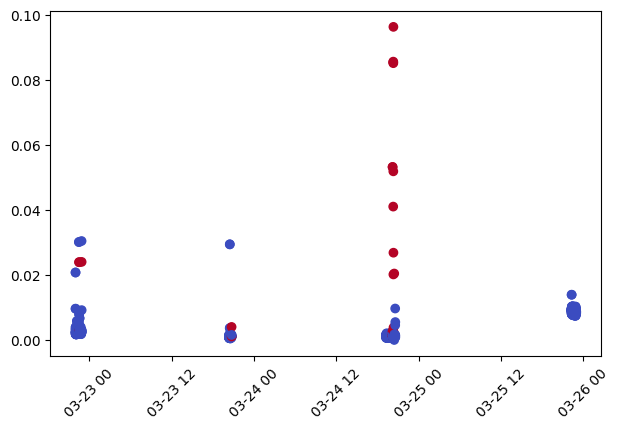

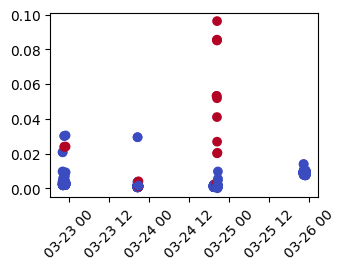

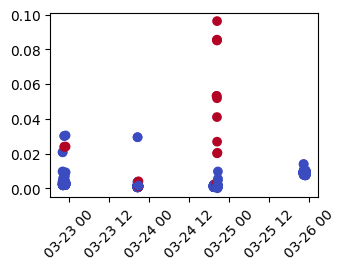

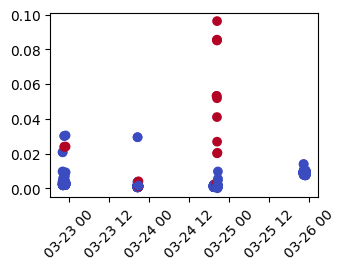

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
metrics = ["requests", "memory", "threads", "cpu"]
plt.figure(figsize=(12, 8))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        df_pivot.index,      # real timestamps
        df_pivot["cpu"],
        c=df_pivot["anomaly"],
        cmap="coolwarm"
    )
   # plt.title(f"{metric.capitalize()} Anomalies")
    #plt.xlabel("Time")    
   # plt.ylabel(metric.capitalize())
   # ax = plt.gca()
    # Show fewer time labels
   # ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    # Format time
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

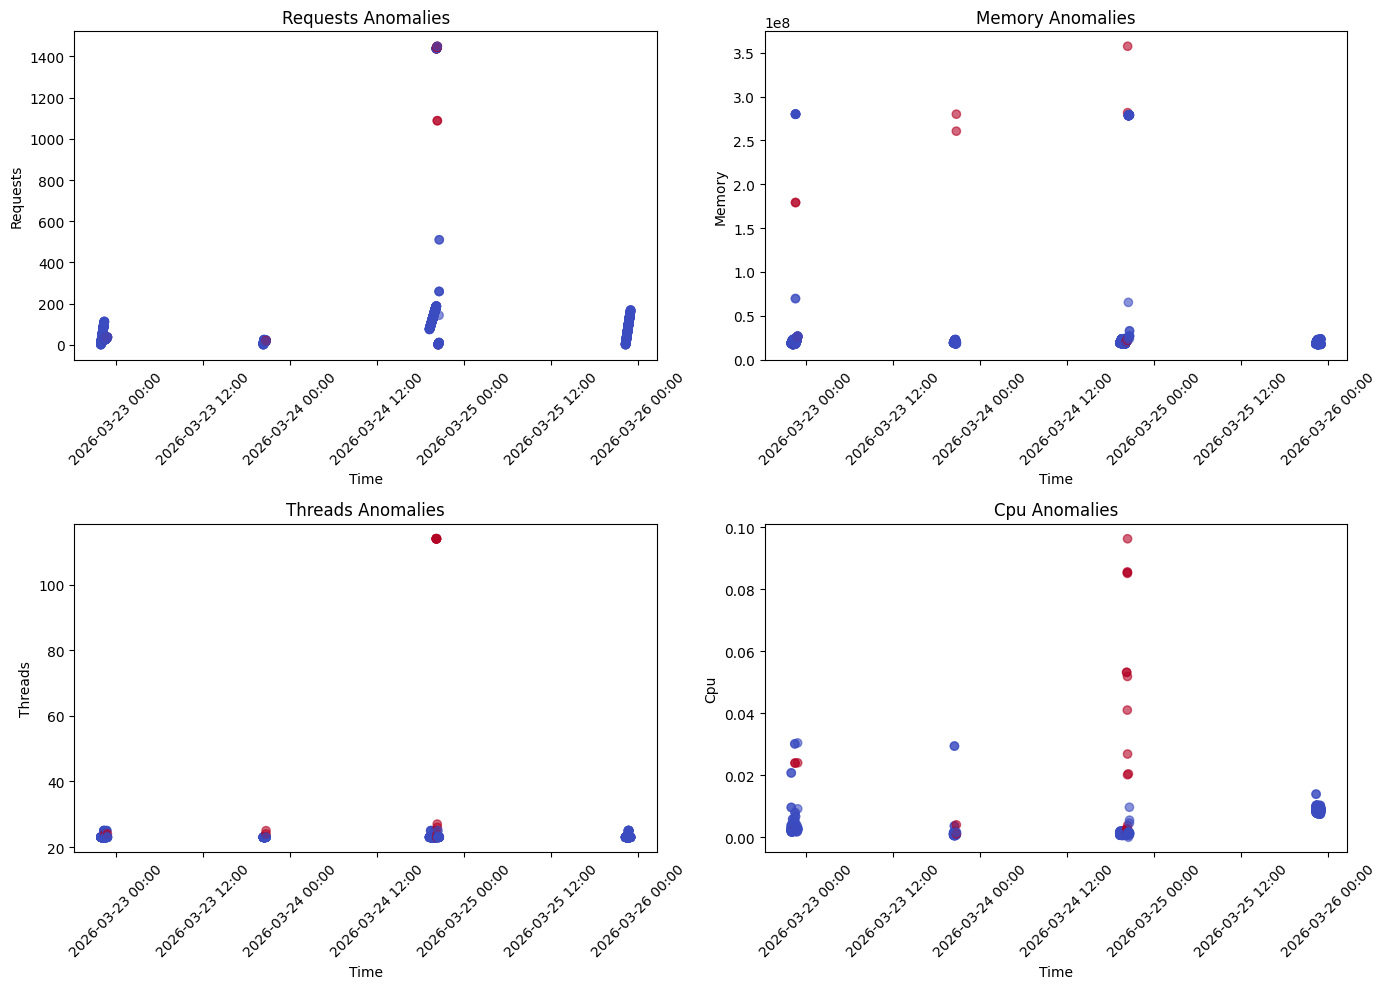

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

metrics = ["requests", "memory", "threads", "cpu"]
plt.figure(figsize=(14, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.scatter(
        df_pivot.index,
        df_pivot[metric],
        c=df_pivot["anomaly"],
        cmap="coolwarm",
        alpha=0.6
    )
    plt.title(f"{metric.capitalize()} Anomalies")
    plt.xlabel("Time")
    plt.ylabel(metric.capitalize())
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42, shuffle=False)

model = IsolationForest(
	n_estimators=100,
	contamination=0.02,
	random_state=42
)

model.fit(X_train)

train_preds = pd.Series(model.predict(X_train), index=X_train.index).map({1: 0, -1: 1})
test_preds = pd.Series(model.predict(X_test), index=X_test.index).map({1: 0, -1: 1})

print("Train rows:", X_train.shape[0], "Anomalies:", train_preds.sum())
print("Test rows:", X_test.shape[0], "Anomalies:", test_preds.sum())

test_results = X_test.assign(anomaly=test_preds)
test_results.head()

Train rows: 907 Anomalies: 19
Test rows: 390 Anomalies: 13


,requests,memory,threads,cpu,anomaly
timestamp,,,,,
2026-03-24 20:14:36.130,1439.333333,21339147.0,23.0,0.001333,0
2026-03-24 20:14:38.316,1439.333333,21339147.0,23.0,0.001333,0
2026-03-24 20:14:51.130,1439.666667,21348889.0,23.0,0.001278,0
2026-03-24 20:14:53.316,1439.666667,21348889.0,23.0,0.001278,0
2026-03-24 20:15:06.130,1440.000000,21618025.0,25.0,0.001139,1


In [23]:
from sklearn.metrics import f1_score, classification_report

y_true = df_pivot.loc[X_test.index, "anomaly"]
y_pred = test_preds

print("F1 score:", f1_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))

F1 score: 0.9166666666666666
              precision    recall  f1-score   support

      normal       1.00      0.99      1.00       379
     anomaly       0.85      1.00      0.92        11

    accuracy                           0.99       390
   macro avg       0.92      1.00      0.96       390
weighted avg       1.00      0.99      1.00       390

